In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit


0.6777 74.71913613009617 74.71913613009617


In [ ]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins, just out to 30/69 for now
r_edges = np.linspace(5, 30, (30-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0 

rlos_edges = np.linspace(0, 60, (60-0)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0 

# bin sim data in bins of R
#vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos  = []
vphyslos = []
rlos_R = []
R_R = []
M_R = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos.append(vpec[mask])
            vphyslos.append(vphys[mask])
            rlos_R.append(rel_rlos[mask])
            R_R.append(rel_R[mask])
            M_R.append(Mvir[mask])



massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [8]:
# and now bins of R, rlos. Also apply 'wrapping' for better statistics: for v's with rlos < 0, treat rlos as |rlos| and vlos < 0 as -vlos (which is then >0). 
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos1 = []
vphyslos1 = []
R1 = []
rlos1 = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        vpec = hdf[f'vpeclos/{str(k)}'][()]
        vphys = hdf[f'vphyslos/{str(k)}'][()]
        
        for i, R in enumerate(r_cens):
            Rmask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])
            rel_R_masked = rel_R[Rmask]
            rel_rlos_masked = rel_rlos[Rmask]
            vpec_masked = vpec[Rmask]
            vphys_masked = vphys[Rmask]

            
            for j, rlos in enumerate(rlos_cens):
                rmask = (np.abs(rel_rlos_masked) >= rlos_edges[j]) & (np.abs(rel_rlos_masked) <= rlos_edges[j+1])
                
                vpeclos1.append(np.sign(rel_rlos_masked[rmask])*vpec_masked[rmask])
                rlos1.append(rel_rlos_masked[rmask])
                R1.append(rel_R_masked[rmask])
                vphyslos1.append(np.sign(rel_rlos_masked[rmask])*vphys_masked[rmask])

In [40]:
# and now bins of R, rlos. To check against the other binning:
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos2 = []
vphyslos2 = []
R2 = []
rlos2 = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        vpec = hdf[f'vpeclos/{str(k)}'][()]
        vphys = hdf[f'vphyslos/{str(k)}'][()]
        
        for i, R in enumerate(r_cens):
            Rmask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])
            rel_R_masked = rel_R[Rmask]
            rel_rlos_masked = rel_rlos[Rmask]
            vpec_masked = vpec[Rmask]
            vphys_masked = vphys[Rmask]

            
            for j, rlos in enumerate(rlos_cens):
                rmask = (rel_rlos_masked >= rlos_edges[j]) & (rel_rlos_masked <= rlos_edges[j+1])
                
                vpeclos2.append(vpec_masked[rmask])
                rlos2.append(rel_rlos_masked[rmask])
                R2.append(rel_R_masked[rmask])
                vphyslos2.append(vphys_masked[rmask])

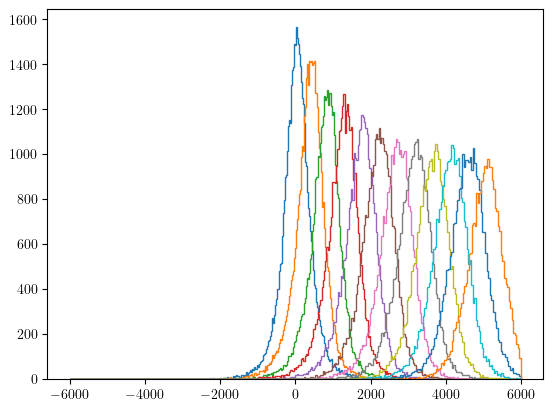

In [12]:
# check 'wrapped' dists

k, j = 0, 5

for i in range(0, len(rlos_cens), 5):
    plt.hist(vphyslos1[i + j*len(rlos_cens) ], bins='auto', range=[-6000, 6000], histtype='step', density=False)

In [ ]:
# define smooth model 

STsm_pars = np.array([132.0358, 2.6771, 0.8615, 1.89826428, -0.82055837, 2.73658808e+02, 1.65323737e-01, 0.10291, -0.0233, 1.16263577, 0.53030107, 13.56176293, 5.279556261331014])

def P_R_smooth(vlos, R, M, pars):
    omA, om_sm, om_sb, om_bmp, om_bms, om_bbp, om_bbs, a_q, a_hm, a_hb, a_mm, a_mb, a_b = pars

    M_p = 1e14

    om_s = line(R, om_sm, om_sb)
    om_bm = plaw(M/M_p, om_bmp, om_bms)
    om_bb = plaw(M/M_p, om_bbp, om_bbs)

    om_b = line(R, om_bm, om_bb)

    a_h = line(R, a_hm, a_hb)
    a_m = line(R, a_mm, a_mb)

    #M_ind = np.where(M == Mvirs)[0][0]

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    rlos_max = 60 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2*rlos_max + 1))
    rlos_vals = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    Pvlos_interp_list = []

    for i in range(len(rlos_vals)):
        r = np.sqrt(R**2 + rlos_vals[i]**2)
        theta = np.arctan2(rlos_vals[i], R)
        sin = np.sin(theta)

        vr_sin = RBinterp(np.log10(M), r).squeeze() * sin #interps[M_ind](r)*sin
        peak = vr_sin + a*H*rlos_vals[i]/h
        ve = np.linspace(peak - 2500, peak + 2500, 100+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        omega = Erf(np.abs(rlos_vals[i]), omA, om_s, om_b)
        alpha = rhml_rad(np.abs(rlos_vals[i]), a_q, a_h, a_m, a_b)

        xi = xi_from_peak_vectorized(modes=vr_sin, omegas=omega, alphas=np.sign(rlos_vals[i])*alpha, nu=nus[0])

        Pvlos = skewed_t_pdf(vc-a*H*rlos_vals[i]/h, xi, omega, np.sign(rlos_vals[i])*alpha, nus[0]) #norm.pdf(vc, loc=peak, scale=Gfixpars[M_ind, R_ind, i, 1])

        interp_func = interp1d(
            vc, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vlos[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_vals), len(vlos))
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)  

    #Pvlos_interp2 = interp1d(rlos_vals, Pvlos_interp, kind='linear', axis=1, bounds_error=False, fill_value=0.0)(rlos_fine)

    integrand = Pvlos_interp * weight[None, :] 

    #integrand = np.concatenate((np.flip(integrand, axis=(0, 1)), integrand), axis=1)

    #print(integrand.shape, Pvlos_interp.shape, Pvlos_interp2.shape, weight.shape, rlos_con_fine.shape)

    P_out = simpson(integrand, x=rlos_vals, axis=1)

    return P_out / np.sum(P_out * np.diff(vlos)[0])
    


In [25]:
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import simpson

def build_vphyslos_interpolator(vphyslos1, rlos_cens, r_cens, Mvirs, vlos_grid):
    """
    Build a RegularGridInterpolator for P(vphyslos | vlos, rlos, R, M).
    
    Args:
        vphyslos1: flat list of vphyslos arrays binned by (M, R, rlos)
        rlos_cens: rlos bin centers
        r_cens: R bin centers
        Mvirs: array of halo masses
        vlos_grid: velocity grid for interpolation
    
    Returns:
        Interpolator callable: interp(vlos, rlos, R, M) -> P(vphyslos | ...)
    """
    n_R = len(r_cens)
    n_rlos = len(rlos_cens)
    n_M = len(Mvirs)
    n_v = len(vlos_grid) - 1  # histogram bins
    
    # Reshape vphyslos1 from flat list to [M, R, rlos]
    vphyslos_3d = np.array(vphyslos1, dtype=object).reshape((n_M, n_R, n_rlos))
    
    # Build 4D histogram: [vlos, rlos, R, M]
    P_grid = np.zeros((n_v, n_rlos, n_R, n_M))
    
    for M_idx in range(n_M):
        for R_idx in range(n_R):
            for rlos_idx in range(n_rlos):
                vphys_data = vphyslos_3d[M_idx, R_idx, rlos_idx]
                if len(vphys_data) > 0:
                    hist, _ = np.histogram(vphys_data, bins=vlos_grid, density=True)
                    P_grid[:, rlos_idx, R_idx, M_idx] = hist
    
    # Create RegularGridInterpolator
    # Dimensions: (vlos_bin_centers, rlos, R, M)
    vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])
    interp = RegularGridInterpolator(
        (vlos_centers, rlos_cens, r_cens, Mvirs),
        P_grid,
        bounds_error=False,
        fill_value=0.0,
        method='linear'
    )
    
    return interp

def P_R_data_wrapped(vlos, R, M, vphyslos_interp, rlos_cens, Mvirs):
    """
    Compute P(vlos | R, M) by integrating over both positive and negative rlos.
    
    Uses symmetry: P(vlos | R, -rlos, M) = P(-vlos | R, rlos, M)
    
    Since vphyslos1 only has data for rlos > 0 (wrapped), we:
    1. Evaluate interpolator at positive rlos only
    2. Construct negative rlos contribution using symmetry: flip vlos and use same rlos weights
    3. Integrate over full rlos range
    """
    rho_g = 0.014  # mean galaxy number density
    
    # Find nearest M index
    M_idx = np.argmin(np.abs(Mvirs - M))
    M_nearest = Mvirs[M_idx]
    
    # Evaluate P(vlos | vlos, rlos, R, M) for positive rlos only
    Pvlos_list = []
    for rlos in rlos_cens:
        pts = np.column_stack([
            vlos,
            np.full_like(vlos, rlos),
            np.full_like(vlos, R),
            np.full_like(vlos, M_nearest)
        ])
        Pvlos_rlos = vphyslos_interp(pts)
        Pvlos_list.append(Pvlos_rlos)
    
    Pvlos_interp_pos = np.array(Pvlos_list).T  # shape: (len(vlos), len(rlos_cens))
    
    # Weight by 3D density (symmetric in rlos)
    r3d_pos = np.sqrt(R**2 + rlos_cens**2)
    weight_pos = rho_g * (cf_inf(r3d_pos, M, jocond.myconfig.cf_pars) + 1)
    
    # Integrand at positive rlos
    integrand_pos = Pvlos_interp_pos * weight_pos[None, :]  # shape: (len(vlos), len(rlos_cens))
    
    # Integrand at negative rlos: use symmetry P(vlos | R, -rlos) = P(-vlos | R, rlos)
    # Flip vlos axis to get P(-vlos | R, rlos)
    integrand_neg = np.flip(Pvlos_interp_pos, axis=0) * weight_pos[None, :]
    
    # Combine: integrate positive + negative contributions
    integrand_total = integrand_pos + integrand_neg  # shape: (len(vlos), len(rlos_cens))
    
    # Integrate over rlos
    P_out = simpson(integrand_total, x=rlos_cens, axis=1)
    
    # Normalize
    return P_out / np.sum(P_out * np.diff(vlos)[0])

# Build interpolator
vlos_grid = np.linspace(-6000, 6000, 201)
vphyslos_interp = build_vphyslos_interpolator(vphyslos1, rlos_cens, r_cens, Mvirs, vlos_grid)

# Example usage:
# P_data = P_R_data_wrapped(vlos_grid, R=10.0, M=1e14, vphyslos_interp=vphyslos_interp, rlos_cens=rlos_cens, Mvirs=Mvirs)

In [26]:
P_data = P_R_data_wrapped(vlos_grid, R=r_cens[5], M=Mvirs[0], vphyslos_interp=vphyslos_interp, rlos_cens=rlos_cens, Mvirs=Mvirs)

In [33]:
r_cens[5]

np.float64(10.5)

In [36]:
def build_vphyslos_interpolator(vphyslos1, rlos_cens, r_cens, Mvirs, vlos_grid):
    """
    Build a RegularGridInterpolator for P(vphyslos | vlos, rlos, R, M).
    Properly accounts for truncation by normalizing counts, not densities.
    """
    n_R = len(r_cens)
    n_rlos = len(rlos_cens)
    n_M = len(Mvirs)
    n_v = len(vlos_grid) - 1  # histogram bins
    
    # Reshape vphyslos1 from flat list to [M, R, rlos]
    vphyslos_3d = np.array(vphyslos1, dtype=object).reshape((n_M, n_R, n_rlos))
    
    # Build 4D histogram: [vlos, rlos, R, M]
    P_grid = np.zeros((n_v, n_rlos, n_R, n_M))
    
    for M_idx in range(n_M):
        for R_idx in range(n_R):
            for rlos_idx in range(n_rlos):
                vphys_data = vphyslos_3d[M_idx, R_idx, rlos_idx]
                if len(vphys_data) > 0:
                    # Use density=False to get counts
                    hist, _ = np.histogram(vphys_data, bins=vlos_grid, density=False)
                    # Count total events (including those outside vlos_grid)
                    total_count = len(vphys_data)
                    # Normalize by total count and bin width to get PDF
                    bin_width = np.diff(vlos_grid)
                    P_grid[:, rlos_idx, R_idx, M_idx] = hist / (total_count * bin_width)
    
    # Create RegularGridInterpolator
    vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])
    interp = RegularGridInterpolator(
        (vlos_centers, rlos_cens, r_cens, Mvirs),
        P_grid,
        bounds_error=False,
        fill_value=0.0,
        method='linear'
    )
    
    return interp

def P_R_data_wrapped(vlos, R, M, vphyslos_interp, rlos_cens, Mvirs):
    """
    Compute P(vlos | R, M) by integrating over rlos using wrapped data.
    Uses symmetry: P(vlos | R, -rlos, M) = P(-vlos | R, rlos, M)
    """
    rho_g = 0.014
    
    M_idx = np.argmin(np.abs(Mvirs - M))
    M_nearest = Mvirs[M_idx]
    
    # Evaluate at positive rlos only
    Pvlos_list = []
    for rlos in rlos_cens:
        pts = np.column_stack([
            vlos,
            np.full_like(vlos, rlos),
            np.full_like(vlos, R),
            np.full_like(vlos, M_nearest)
        ])
        Pvlos_rlos = vphyslos_interp(pts)
        Pvlos_list.append(Pvlos_rlos)
    
    Pvlos_interp_pos = np.array(Pvlos_list).T  # (len(vlos), len(rlos_cens))
    
    r3d_pos = np.sqrt(R**2 + rlos_cens**2)
    weight_pos = rho_g * (cf_inf(r3d_pos, M, jocond.myconfig.cf_pars) + 1)
    
    # Integrand at positive rlos
    integrand_pos = Pvlos_interp_pos * weight_pos[None, :]
    
    # Integrand at negative rlos: use symmetry
    integrand_neg = np.flip(Pvlos_interp_pos, axis=0) * weight_pos[None, :]
    
    # Total integrand (both positive and negative rlos)
    integrand_total = integrand_pos + integrand_neg
    
    # Integrate over rlos
    P_out = simpson(integrand_total, x=rlos_cens, axis=1)
    
    # Ensure symmetry by averaging P(v) and P(-v)
    P_sym = 0.5 * (P_out + np.flip(P_out))
    
    # Normalize
    return P_sym / np.sum(P_sym * np.diff(vlos)[0])

In [37]:
# Build interpolator with wider grid
vlos_grid_wide = np.linspace(-6000, 6000, 301)
vphyslos_interp = build_vphyslos_interpolator(vphyslos1, rlos_cens, r_cens, Mvirs, vlos_grid_wide)


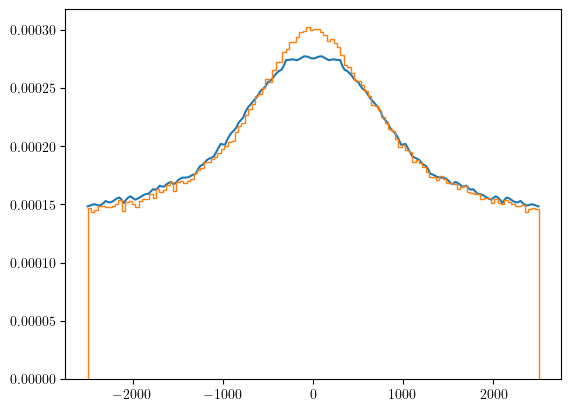

In [38]:
vlos_grid = np.linspace(-2500, 2500, 201)
vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])

P_data = P_R_data_wrapped(vlos_grid, R=r_cens[5], M=Mvirs[0], vphyslos_interp=vphyslos_interp, rlos_cens=rlos_cens, Mvirs=Mvirs)

plt.plot(vlos_grid, P_data, )
hist = plt.hist(vphyslos[5], bins='auto', range=[-2500, 2500], histtype='step', density=True)

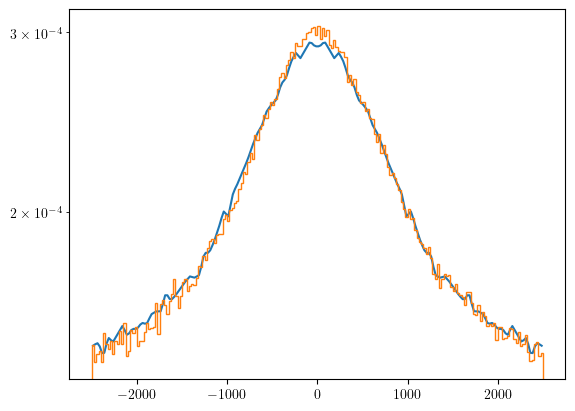

In [50]:
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import simpson

def build_vphyslos2_interpolator(vphyslos2, rlos_cens, r_cens, Mvirs, vlos_grid):
    """
    Build a RegularGridInterpolator for P(vphyslos | vlos, rlos, R, M) using unwrapped data.
    """
    n_R = len(r_cens)
    n_rlos = len(rlos_cens)
    n_M = len(Mvirs)
    n_v = len(vlos_grid) - 1
    
    vphyslos_3d = np.array(vphyslos2, dtype=object).reshape((n_M, n_R, n_rlos))
    P_grid = np.zeros((n_v, n_rlos, n_R, n_M))
    
    for M_idx in range(n_M):
        for R_idx in range(n_R):
            for rlos_idx in range(n_rlos):
                vphys_data = vphyslos_3d[M_idx, R_idx, rlos_idx]
                if len(vphys_data) > 0:
                    hist, _ = np.histogram(vphys_data, bins=vlos_grid, density=False)
                    total_count = len(vphys_data)
                    bin_width = np.diff(vlos_grid)
                    P_grid[:, rlos_idx, R_idx, M_idx] = hist / (total_count * bin_width)
    
    vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])
    interp = RegularGridInterpolator(
        (vlos_centers, rlos_cens, r_cens, Mvirs),
        P_grid,
        bounds_error=False,
        fill_value=0.0,
        method='linear'
    )
    
    return interp

def P_R_data_unwrapped(vlos, R, M, vphyslos2_interp, rlos_cens, Mvirs):
    """
    Compute P(vlos | R, M) by integrating over rlos using unwrapped data.
    """
    rho_g = 0.014
    
    M_idx = np.argmin(np.abs(Mvirs - M))
    M_nearest = Mvirs[M_idx]
    
    # Evaluate at all rlos (both positive and negative)
    rlos_all = np.concatenate([-rlos_cens[::-1], rlos_cens])
    Pvlos_list = []
    
    for rlos in rlos_all:
        pts = np.column_stack([
            vlos,
            np.full_like(vlos, rlos),
            np.full_like(vlos, R),
            np.full_like(vlos, M_nearest)
        ])
        Pvlos_rlos = vphyslos2_interp(pts)
        Pvlos_list.append(Pvlos_rlos)
    
    Pvlos_interp = np.array(Pvlos_list).T  # (len(vlos), len(rlos_all))
    
    r3d = np.sqrt(R**2 + rlos_all**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)
    
    integrand = Pvlos_interp * weight[None, :]
    
    # Integrate over rlos
    P_out = simpson(integrand, x=rlos_all, axis=1)
    
    # Enforce symmetry: P(v) = P(-v)
    P_sym = 0.5 * (P_out + np.flip(P_out))
    
    # Normalize
    return P_sym / np.sum(P_sym * np.diff(vlos)[0])


# Build interpolator with unwrapped data
vlos_grid_wide = np.linspace(-8000, 8000, 301)
vphyslos2_interp = build_vphyslos2_interpolator(vphyslos2, rlos_cens, r_cens, Mvirs, vlos_grid_wide)

# Evaluate at narrower grid for plotting
vlos_grid = np.linspace(-2500, 2500, 201)
vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])

P_data = P_R_data_unwrapped(vlos_centers, R=r_cens[5], M=Mvirs[0], vphyslos2_interp=vphyslos2_interp, rlos_cens=rlos_cens, Mvirs=Mvirs)

plt.plot(vlos_centers, P_data)
hist = plt.hist(vphyslos[5], bins=vlos_grid, histtype='step', density=True)
plt.yscale('log')

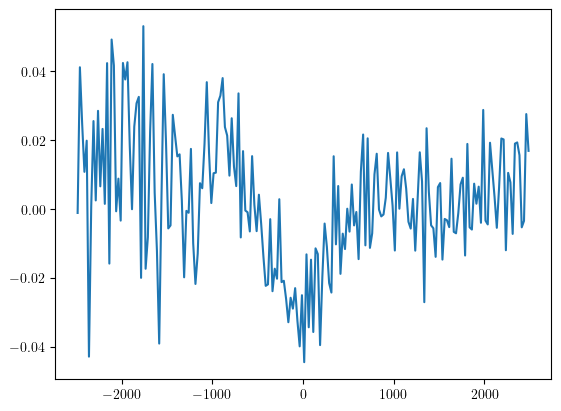

In [51]:
plt.plot(vlos_centers, (P_data - hist[0])/hist[0])

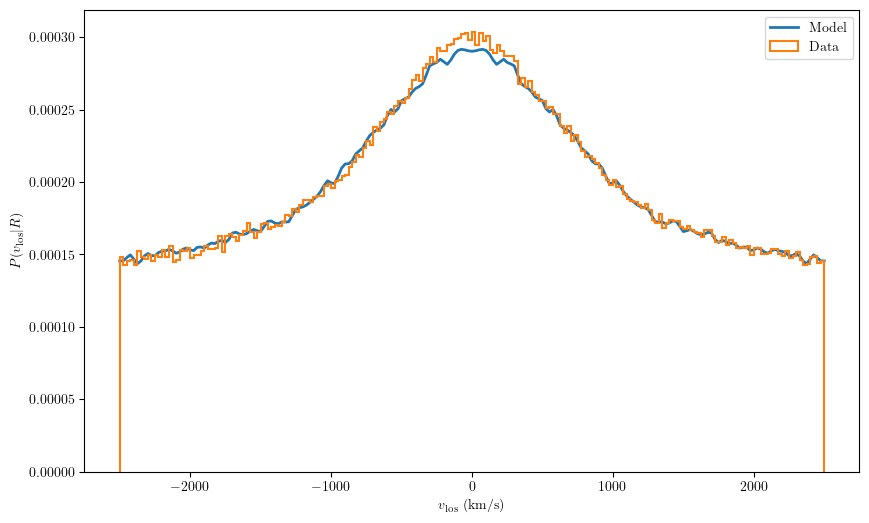

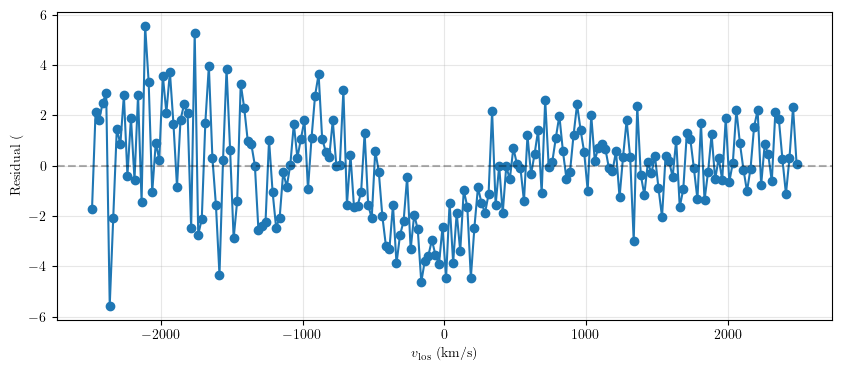

In [52]:
def build_vphyslos2_interpolator(vphyslos2, rlos_cens, r_cens, Mvirs, vlos_grid):
    """
    Build a RegularGridInterpolator for P(vphyslos | vlos, rlos, R, M) using unwrapped data.
    Uses cubic interpolation for smoother PDF estimation.
    """
    n_R = len(r_cens)
    n_rlos = len(rlos_cens)
    n_M = len(Mvirs)
    n_v = len(vlos_grid) - 1
    
    vphyslos_3d = np.array(vphyslos2, dtype=object).reshape((n_M, n_R, n_rlos))
    P_grid = np.zeros((n_v, n_rlos, n_R, n_M))
    
    for M_idx in range(n_M):
        for R_idx in range(n_R):
            for rlos_idx in range(n_rlos):
                vphys_data = vphyslos_3d[M_idx, R_idx, rlos_idx]
                if len(vphys_data) > 0:
                    hist, _ = np.histogram(vphys_data, bins=vlos_grid, density=False)
                    total_count = len(vphys_data)
                    bin_width = np.diff(vlos_grid)
                    # Normalize properly accounting for truncation
                    P_grid[:, rlos_idx, R_idx, M_idx] = hist / (total_count * bin_width)
    
    vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])
    interp = RegularGridInterpolator(
        (vlos_centers, rlos_cens, r_cens, Mvirs),
        P_grid,
        bounds_error=False,
        fill_value=0.0,
        method='cubic'  # Use cubic instead of linear
    )
    
    return interp

def P_R_data_unwrapped(vlos, R, M, vphyslos2_interp, rlos_cens, Mvirs):
    """
    Compute P(vlos | R, M) by integrating over rlos using unwrapped data.
    Uses finer rlos sampling for more accurate integration.
    """
    rho_g = 0.014
    
    M_idx = np.argmin(np.abs(Mvirs - M))
    M_nearest = Mvirs[M_idx]
    
    # Evaluate at all rlos (both positive and negative)
    rlos_all = np.concatenate([-rlos_cens[::-1], rlos_cens])
    Pvlos_list = []
    
    for rlos in rlos_all:
        pts = np.column_stack([
            vlos,
            np.full_like(vlos, rlos),
            np.full_like(vlos, R),
            np.full_like(vlos, M_nearest)
        ])
        Pvlos_rlos = vphyslos2_interp(pts)
        Pvlos_list.append(Pvlos_rlos)
    
    Pvlos_interp = np.array(Pvlos_list).T  # (len(vlos), len(rlos_all))
    
    r3d = np.sqrt(R**2 + rlos_all**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)
    
    integrand = Pvlos_interp * weight[None, :]
    
    # Integrate over rlos using higher-order method
    P_out = simpson(integrand, x=rlos_all, axis=1)
    
    # Enforce symmetry: P(v) = P(-v)
    P_sym = 0.5 * (P_out + np.flip(P_out))
    
    # Normalize with high precision
    norm = np.sum(P_sym * np.diff(vlos)[0])
    return P_sym / norm


# Build interpolator with finer velocity grid
vlos_grid_wide = np.linspace(-8000, 8000, 401)  # Increased from 301
vphyslos2_interp = build_vphyslos2_interpolator(vphyslos2, rlos_cens, r_cens, Mvirs, vlos_grid_wide)

# Evaluate at narrower grid for plotting
vlos_grid = np.linspace(-2500, 2500, 201)

P_data = P_R_data_unwrapped(vlos_grid, R=r_cens[5], M=Mvirs[0], vphyslos2_interp=vphyslos2_interp, rlos_cens=rlos_cens, Mvirs=Mvirs)

plt.figure(figsize=(10, 6))
plt.plot(vlos_grid, P_data, linewidth=2, label='Model')
hist = plt.hist(vphyslos[5], bins=vlos_grid, histtype='step', density=True, linewidth=1.5, label='Data')
plt.xlabel(r'$v_{\mathrm{los}}$ (km/s)')
plt.ylabel(r'$P(v_{\mathrm{los}} | R)$')
plt.legend()
plt.show()

# Compute residuals
hist_vals = np.histogram(vphyslos[5], bins=vlos_grid)[0]
hist_vals = hist_vals / (np.sum(hist_vals) * np.diff(vlos_grid)[0])
vlos_centers = 0.5 * (vlos_grid[:-1] + vlos_grid[1:])
residuals = (P_data[:-1] - hist_vals) / hist_vals
plt.figure(figsize=(10, 4))
plt.plot(vlos_centers, residuals * 100, 'o-')
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.ylabel('Residual (%)')
plt.xlabel(r'$v_{\mathrm{los}}$ (km/s)')
plt.grid(alpha=0.3)
plt.show()